# A classification model with the Titanic Dataset

In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
#imported needed libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
#imported my file (the titanic dataset)
titanic_data = pd.read_csv('data/titanic.csv')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,PaCh,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [5]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Name      887 non-null    object 
 3   Sex       887 non-null    object 
 4   Age       887 non-null    float64
 5   SibSp     887 non-null    int64  
 6   PaCh      887 non-null    int64  
 7   Fare      887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [6]:
#Encoded the sex column, so it's in figures
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)

encoded_sex = encoder.fit_transform(titanic_data[['Sex']])

encoded_sex = pd.DataFrame(encoded_sex, columns=encoder.get_feature_names_out())

encoded_sex.head()

,Sex_female,Sex_male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1


In [7]:
# Dropped the old Sex column
clean_data = pd.concat([titanic_data.drop('Sex', axis=1), encoded_sex], axis=1)

clean_data.head()

,Survived,Pclass,Name,Age,SibSp,PaCh,Fare,Sex_female,Sex_male
0,0,3,Mr. Owen Harris Braund,22.0,1,0,7.2500,0,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,38.0,1,0,71.2833,1,0
2,1,3,Miss. Laina Heikkinen,26.0,0,0,7.9250,1,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,35.0,1,0,53.1000,1,0
4,0,3,Mr. William Henry Allen,35.0,0,0,8.0500,0,1


In [8]:
#Encoded the PClass
encoded_pclass = encoder.fit_transform(titanic_data[['Pclass']])

encoded_pclass = pd.DataFrame(encoded_pclass, columns=encoder.get_feature_names_out())
    
encoded_pclass.head()

,Pclass_1,Pclass_2,Pclass_3
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,0,0,1


In [9]:
# Added it to the main dataset
clean_data = pd.concat([clean_data.drop('Pclass', axis=1), encoded_pclass], axis=1)
    
clean_data.head()

,Survived,Name,Age,SibSp,PaCh,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,0,Mr. Owen Harris Braund,22.0,1,0,7.2500,0,1,0,0,1
1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,38.0,1,0,71.2833,1,0,1,0,0
2,1,Miss. Laina Heikkinen,26.0,0,0,7.9250,1,0,0,0,1
3,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,35.0,1,0,53.1000,1,0,1,0,0
4,0,Mr. William Henry Allen,35.0,0,0,8.0500,0,1,0,0,1


In [10]:
# Dropped the name, it has no effect on our target
clean_data.drop(['Name'], axis=1, inplace=True)

clean_data.head()

,Survived,Age,SibSp,PaCh,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,1,0,0
4,0,35.0,0,0,8.0500,0,1,0,0,1


In [11]:
#Seperated the target from the features
X = clean_data.drop('Survived', axis=1)

y = clean_data['Survived']

In [12]:
# Split data into test and training and chose a random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [13]:
# Picked a model
log_model = LogisticRegression(max_iter=300)

In [14]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [15]:
# Tested the model
predictions = log_model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

accuracy_score(y_test, predictions)

0.7715355805243446

In [17]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       162
           1       0.70      0.72      0.71       105

    accuracy                           0.77       267
   macro avg       0.76      0.76      0.76       267
weighted avg       0.77      0.77      0.77       267



In [18]:
confusion_matrix(y_test, predictions)

array([[130,  32],
       [ 29,  76]])

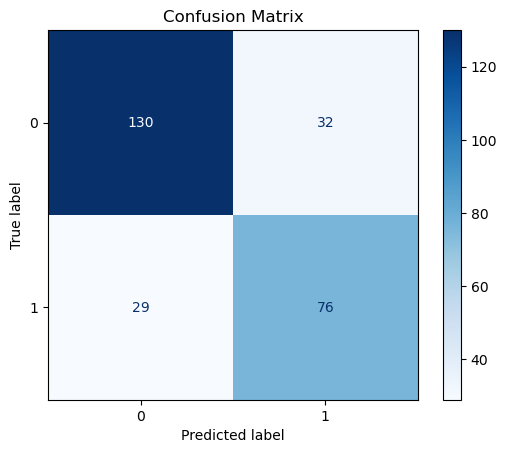

In [19]:
import matplotlib.pyplot as plt
cm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, predictions))
cm_display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
# plt.colorbar()
plt.show()

# Trained Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


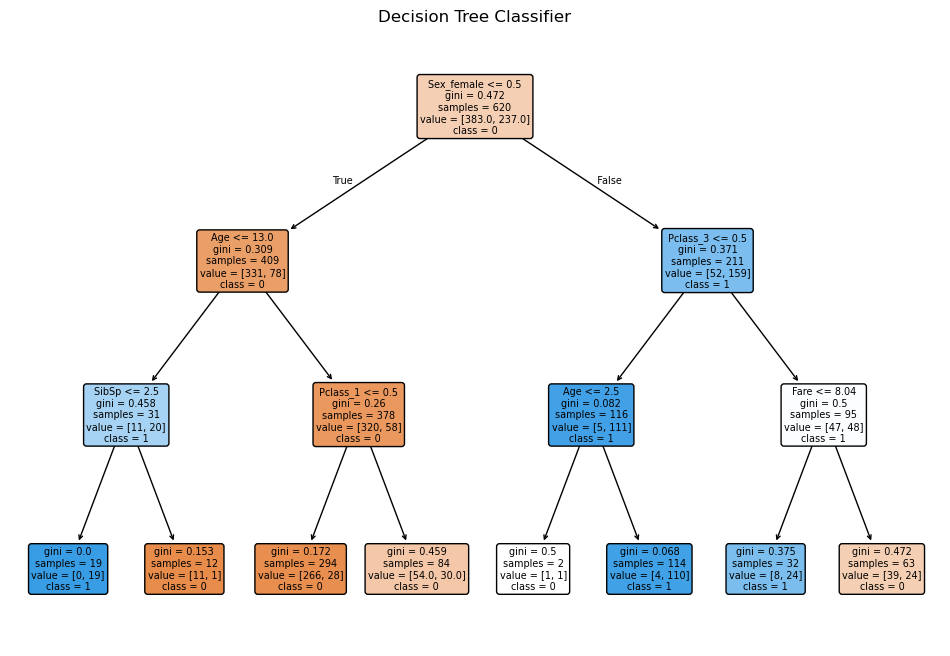

In [22]:
plt.figure(figsize=(12, 8))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['0', '1'],
          filled=True, rounded=True)
plt.title("Decision Tree Classifier")
plt.show()

In [23]:
# Made predictions vs check accuracy

y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.80


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       162
           1       0.84      0.60      0.70       105

    accuracy                           0.80       267
   macro avg       0.81      0.76      0.77       267
weighted avg       0.80      0.80      0.79       267



In [26]:
confusion_matrix(y_test, y_pred)

array([[150,  12],
       [ 42,  63]])

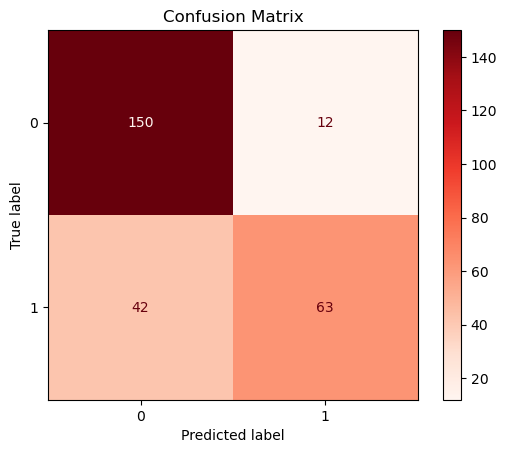

In [27]:
cm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
cm_display.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix')
plt.show()

In [28]:
#Used a pipieline
X = titanic_data[['Pclass', 'Sex', 'Age', 'SibSp']]
y = titanic_data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['Pclass', 'Sex']
preprocessor = ColumnTransformer(transformers=[
 ('cat', OneHotEncoder(), categorical_features)
])

lr_pipeline = Pipeline(steps=[
 ('preprocessor', preprocessor),
 ('classifier', LogisticRegression(max_iter=300))
])

In [30]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
#prediction function to test the model on unseen data to test its accuracy/precision.

def predict_survival(name: str, Pclass: int, Sex: str, Age: float, SibSp: int) -> str:
    """
    Predict survival using our model
    """
    # 1. Create the input DataFrame
    input_data = pd.DataFrame({
        'Pclass': [Pclass],
        'Sex': [Sex],
        'Age': [Age],
        'SibSp': [SibSp]
    })

    # 2. Predict using your pre-trained pipeline
    prediction = lr_pipeline.predict(input_data)[0]
    
    # 3. Determine the output message based on the prediction
    if prediction == 0:
        result = f'Wooo 😮 {name.title()}, you Died 😢 '
    else:
        result = f'Cheers 🥂 {name.title()}, you Survived 😁 '

    return result


In [32]:
print(predict_survival('Benjamin', Pclass=3, Sex="male", Age=25.0, SibSp=0))

Wooo 😮 Benjamin, you Died 😢 


In [33]:
print(predict_survival('Carina', Pclass=1, Sex="female", Age=30.0, SibSp=0))

Cheers 🥂 Carina, you Survived 😁 
